<a href="https://colab.research.google.com/github/anafrodrigues95-rgc/geomodelagem_uenf/blob/main/Mapas_acai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# INSTALAÇÃO DAS BIBLIOTECAS NECESSÁRIAS
# ==============================================================================
!pip install -q cdsapi netcdf4 h5netcdf cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.0 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==============================================================================
import cdsapi
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import calendar

In [ ]:
# ==============================================================================
# ÁREA DE ESTUDO (mesma região usada nas análises de Earth Engine, para manter
# a atividade toda coerente entre as partes)
# ==============================================================================
lat_norte, lat_sul = -1.4, -2.6
lon_oeste, lon_leste = -49.8, -48.5

municipios = {
    'Igarapé-Miri': (-48.9578, -1.9987),
    'Cametá':        (-49.4956, -2.2504),
    'Abaetetuba':    (-48.8788, -1.7217),
    'Belém (capital)': (-48.4902, -1.4558),
}

para_extent = [-58.9, -46.0, -9.9, 2.6]  # extensão do Estado do Pará

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Do

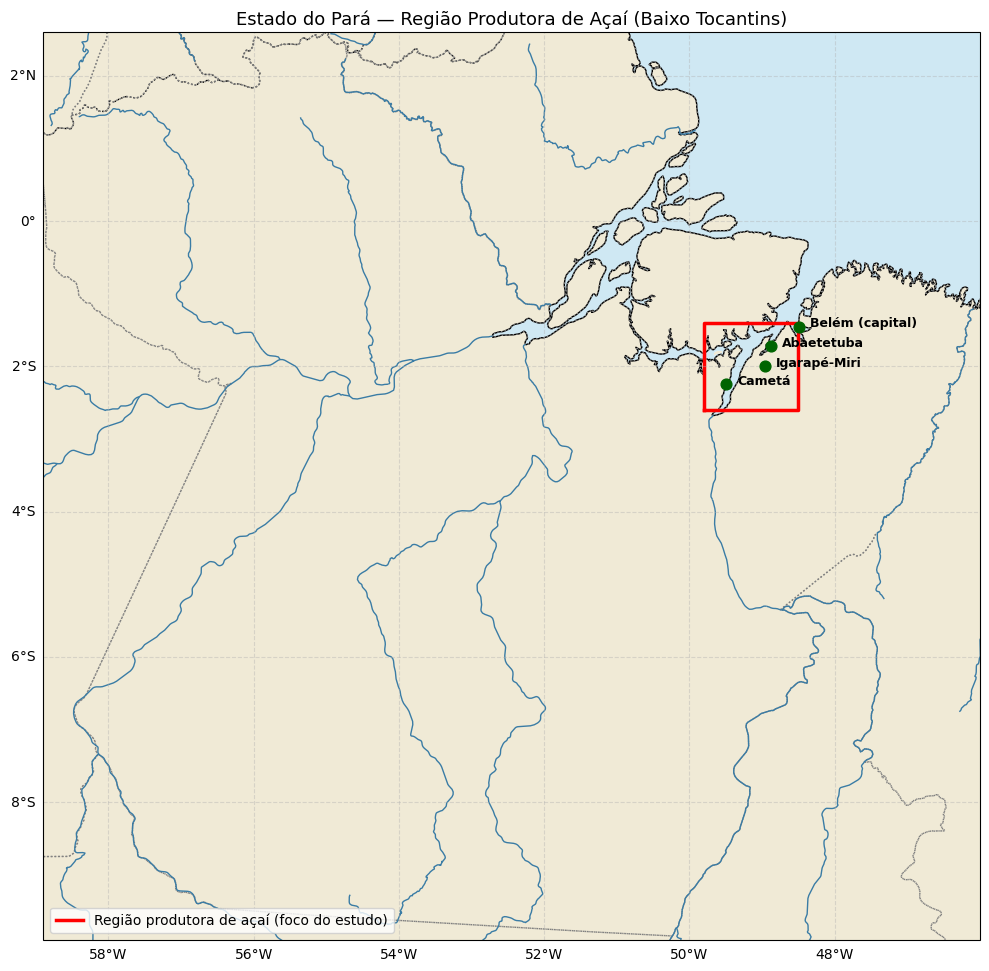

In [ ]:
# ==============================================================================
# MAPA GERAL DO PARÁ COM A REGIÃO PRODUTORA DE AÇAÍ DESTACADA
# ==============================================================================
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(para_extent, crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='#f0ead6')
ax.add_feature(cfeature.OCEAN, facecolor='#cfe8f3')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')
ax.add_feature(cfeature.RIVERS, edgecolor='#3a7ca5')

ax.plot(
    [lon_oeste, lon_leste, lon_leste, lon_oeste, lon_oeste],
    [lat_sul, lat_sul, lat_norte, lat_norte, lat_sul],
    color='red', linewidth=2.5, transform=ccrs.PlateCarree(),
    label='Região produtora de açaí (foco do estudo)'
)

for nome, (lon, lat) in municipios.items():
    ax.scatter(lon, lat, s=60, color='darkgreen', marker='o',
               transform=ccrs.PlateCarree(), zorder=5)
    ax.text(lon + 0.15, lat, nome, transform=ccrs.PlateCarree(),
            fontsize=9, fontweight='bold')

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
gl.top_labels = False
gl.right_labels = False

plt.title('Estado do Pará — Região Produtora de Açaí (Baixo Tocantins)', fontsize=13)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('mapa_regiao_acai_para.png', dpi=150)
plt.show()

In [ ]:
# ==============================================================================
# CONEXÃO COM A API DO COPERNICUS (CDS)
# ==============================================================================

CDS_URL = "https://cds.climate.copernicus.eu/api"
CDS_KEY = "1e59e4ff-9b93-4cff-8896-edd8ab12b379"


client = cdsapi.Client(url=CDS_URL, key=CDS_KEY, verify=False)

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [ ]:
# ==============================================================================
# ESTAÇÕES DO ANO, HORÁRIO E ÁREA PARA O DOWNLOAD
# ==============================================================================
ANO = 2024
HORA_UTC = '18:00'  # 15h local de Belém (UTC-3)

estacoes = {
    'Verao':     [12, 1, 2],
    'Outono':    [3, 4, 5],
    'Inverno':   [6, 7, 8],
    'Primavera': [9, 10, 11],
}

area_estudo = [lat_norte, lon_oeste, lat_sul, lon_leste]  # [Norte, Oeste, Sul, Leste]

def dias_do_mes(ano, mes):
    return [f'{d:02d}' for d in range(1, calendar.monthrange(ano, mes)[1] + 1)]

In [ ]:
# ==============================================================================
# DOWNLOAD DOS DADOS HORÁRIOS (temperatura, vento, ponto de orvalho) POR ESTAÇÃO
# ==============================================================================
def baixar_dados_horarios(nome_estacao, meses):
    dias = sorted(set(d for m in meses for d in dias_do_mes(ANO, m)))
    dataset = 'reanalysis-era5-land'
    request = {
        'variable': [
            '2m_temperature',
            '2m_dewpoint_temperature',
            '10m_u_component_of_wind',
            '10m_v_component_of_wind',
        ],
        'year': [str(ANO)],
        'month': [f'{m:02d}' for m in meses],
        'day': dias,
        'time': [HORA_UTC],
        'area': area_estudo,
        'data_format': 'netcdf',
        'download_format': 'unarchived',
    }
    arquivo = f'era5land_horario_{nome_estacao}.nc'
    client.retrieve(dataset, request).download(arquivo)
    return arquivo

arquivos_horarios = {}
for nome, meses in estacoes.items():
    print(f'⬇️  Baixando dados horários — {nome}...')
    arquivos_horarios[nome] = baixar_dados_horarios(nome, meses)
print('✅ Downloads horários concluídos.')

⬇️  Baixando dados horários — Verao...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-07-06 21:21:37,695 INFO Request ID is e19d303c-9769-4c8f-9a72-a6306bdc6652
INFO:ecmwf.datastores.legacy_client:Request ID is e19d303c-9769-4c8f-9a72-a6306bdc6652
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate 

b604bcb93a6847f8021b8da4860558bf.nc:   0%|          | 0.00/189k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


⬇️  Baixando dados horários — Outono...


...

⬇️  Baixando dados horários — Primavera...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-07-06 21:22:41,472 INFO Request ID is 17006262-cb7f-4d79-9686-f864f2a0b159
INFO:ecmwf.datastores.legacy_client:Request ID is 17006262-cb7f-4d79-9686-f864f2a0b159
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate 

e7e4ff52ea4bd93302eadefadc9fa017.nc:   0%|          | 0.00/188k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


✅ Downloads horários concluídos.


In [ ]:
# ==============================================================================
# DOWNLOAD DA PRECIPITAÇÃO (médias mensais, os 12 meses de 2024 de uma vez)
# ==============================================================================
def baixar_precipitacao_mensal(meses):
    dataset = 'reanalysis-era5-land-monthly-means'
    request = {
        'product_type': ['monthly_averaged_reanalysis'],
        'variable': ['total_precipitation'],
        'year': [str(ANO)],
        'month': [f'{m:02d}' for m in meses],
        'time': ['00:00'],
        'area': area_estudo,
        'data_format': 'netcdf',
        'download_format': 'unarchived',
    }
    arquivo = 'era5land_precip_todos_meses.nc'
    client.retrieve(dataset, request).download(arquivo)
    return arquivo

arquivo_precip = baixar_precipitacao_mensal(list(range(1, 13)))
print('✅ Download de precipitação concluído.')

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-07-06 21:23:20,749 INFO Request ID is 3ae2f5c5-0d41-4935-9ba6-f0ce71e4affd
INFO:ecmwf.datastores.legacy_client:Request ID is 3ae2f5c5-0d41-4935-9ba6-f0ce71e4affd
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate 

d9453f803f33474f1e2e98c2dc849c7e.nc:   0%|          | 0.00/31.2k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


✅ Download de precipitação concluído.


In [ ]:
# ==============================================================================
# UMIDADE RELATIVA (fórmula de Magnus) E MÉDIAS SAZONAIS
# ==============================================================================
def calcula_umidade_relativa(temp_c, orvalho_c):
    a, b = 17.625, 243.04
    es  = np.exp((a * temp_c) / (b + temp_c))
    ed  = np.exp((a * orvalho_c) / (b + orvalho_c))
    return 100 * (ed / es)

dados_sazonais = {}

for nome_estacao in estacoes:
    ds = xr.open_dataset(arquivos_horarios[nome_estacao])

    t2m_c = ds['t2m'] - 273.15
    d2m_c = ds['d2m'] - 273.15
    vento = np.sqrt(ds['u10']**2 + ds['v10']**2)
    rh = calcula_umidade_relativa(t2m_c, d2m_c)

    dados_sazonais[nome_estacao] = {
        'temperatura': t2m_c.mean(dim='valid_time'),
        'vento':       vento.mean(dim='valid_time'),
        'umidade':     rh.mean(dim='valid_time'),
    }

print('✅ Médias sazonais de temperatura, vento e umidade calculadas.')

✅ Médias sazonais de temperatura, vento e umidade calculadas.


In [ ]:
# ==============================================================================
# PRECIPITAÇÃO: CONVERSÃO PRA mm/dia E AGRUPAMENTO POR ESTAÇÃO
# ==============================================================================
ds_precip = xr.open_dataset(arquivo_precip)
precip_mm_dia = ds_precip['tp'] * 1000  # metros -> milímetros

for nome_estacao, meses in estacoes.items():
    meses_no_arquivo = ds_precip['valid_time'].dt.month.isin(meses)
    dados_sazonais[nome_estacao]['precipitacao'] = (
        precip_mm_dia.sel(valid_time=meses_no_arquivo).mean(dim='valid_time')
    )

print('✅ Precipitação sazonal (mm/dia) calculada.')

✅ Precipitação sazonal (mm/dia) calculada.


In [ ]:
# ==============================================================================
# FUNÇÃO PARA PLOTAR UMA VARIÁVEL NAS 4 ESTAÇÕES (grade 2x2)
# ==============================================================================
variaveis_plot = {
    'temperatura':   {'titulo': 'Temperatura do Ar (°C)', 'cmap': 'inferno', 'unidade': '°C'},
    'precipitacao':  {'titulo': 'Precipitação (mm/dia)',   'cmap': 'Blues',   'unidade': 'mm/dia'},
    'vento':         {'titulo': 'Intensidade do Vento (m/s)', 'cmap': 'viridis', 'unidade': 'm/s'},
    'umidade':       {'titulo': 'Umidade Relativa (%)',    'cmap': 'BuGn',    'unidade': '%'},
}

ordem_estacoes = ['Verao', 'Outono', 'Inverno', 'Primavera']

def plota_variavel_4_estacoes(chave_var):
    info = variaveis_plot[chave_var]
    fig, axes = plt.subplots(
        2, 2, figsize=(12, 10),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    for ax, nome_estacao in zip(axes.flat, ordem_estacoes):
        campo = dados_sazonais[nome_estacao][chave_var]

        # preenche pixels de água (NaN no ERA5-Land) por interpolação
        # a partir dos vizinhos de terra, evitando "buracos" brancos no mapa
        campo_plot = (
            campo.sortby('latitude')
                 .interpolate_na(dim='longitude', method='nearest')
                 .interpolate_na(dim='latitude', method='nearest')
                 .bfill(dim='longitude').ffill(dim='longitude')
                 .bfill(dim='latitude').ffill(dim='latitude')
        )

        ax.set_extent([lon_oeste, lon_leste, lat_sul, lat_norte],
                      crs=ccrs.PlateCarree())

        cs = ax.contourf(
            campo_plot['longitude'], campo_plot['latitude'], campo_plot,
            levels=12, cmap=info['cmap'], transform=ccrs.PlateCarree()
        )
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.RIVERS, edgecolor='blue', alpha=0.4)

        for nome_mun, (lon, lat) in municipios.items():
            if nome_mun != 'Belém (capital)':
                ax.scatter(lon, lat, s=25, color='black', marker='^',
                           transform=ccrs.PlateCarree())
                ax.text(lon + 0.03, lat, nome_mun, fontsize=7,
                        transform=ccrs.PlateCarree())

        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
        gl.top_labels = False
        gl.right_labels = False
        ax.set_title(nome_estacao, fontsize=11, fontweight='bold')

        fig.colorbar(cs, ax=ax, orientation='vertical', shrink=0.8,
                     label=info['unidade'])

    fig.suptitle(f"{info['titulo']} — 2024, 15h (hora local)", fontsize=15)
    plt.tight_layout()
    plt.savefig(f'mapa_sazonal_{chave_var}.png', dpi=150)
    plt.show()

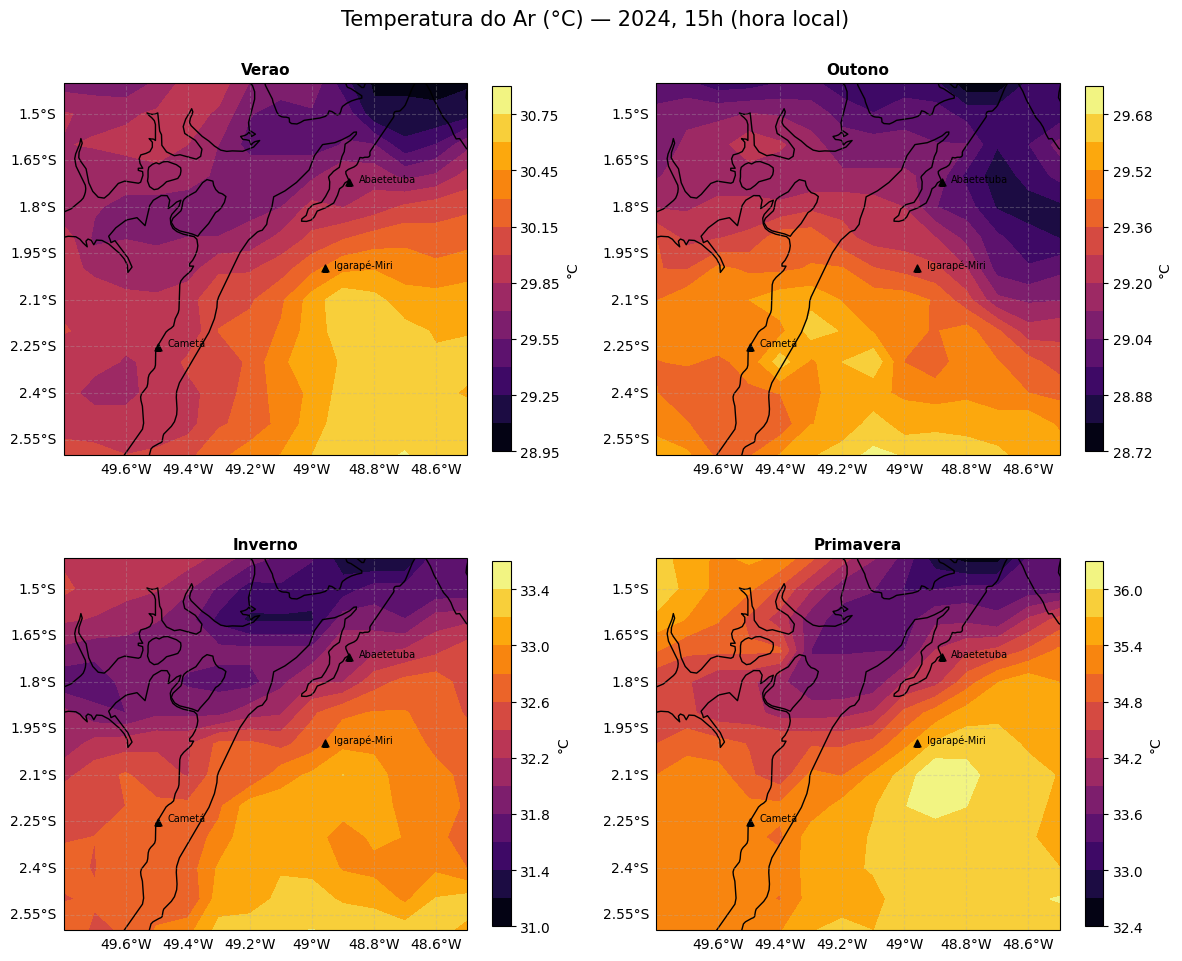

In [ ]:
# ==============================================================================
# MAPA 1 — TEMPERATURA
# ==============================================================================
plota_variavel_4_estacoes('temperatura')

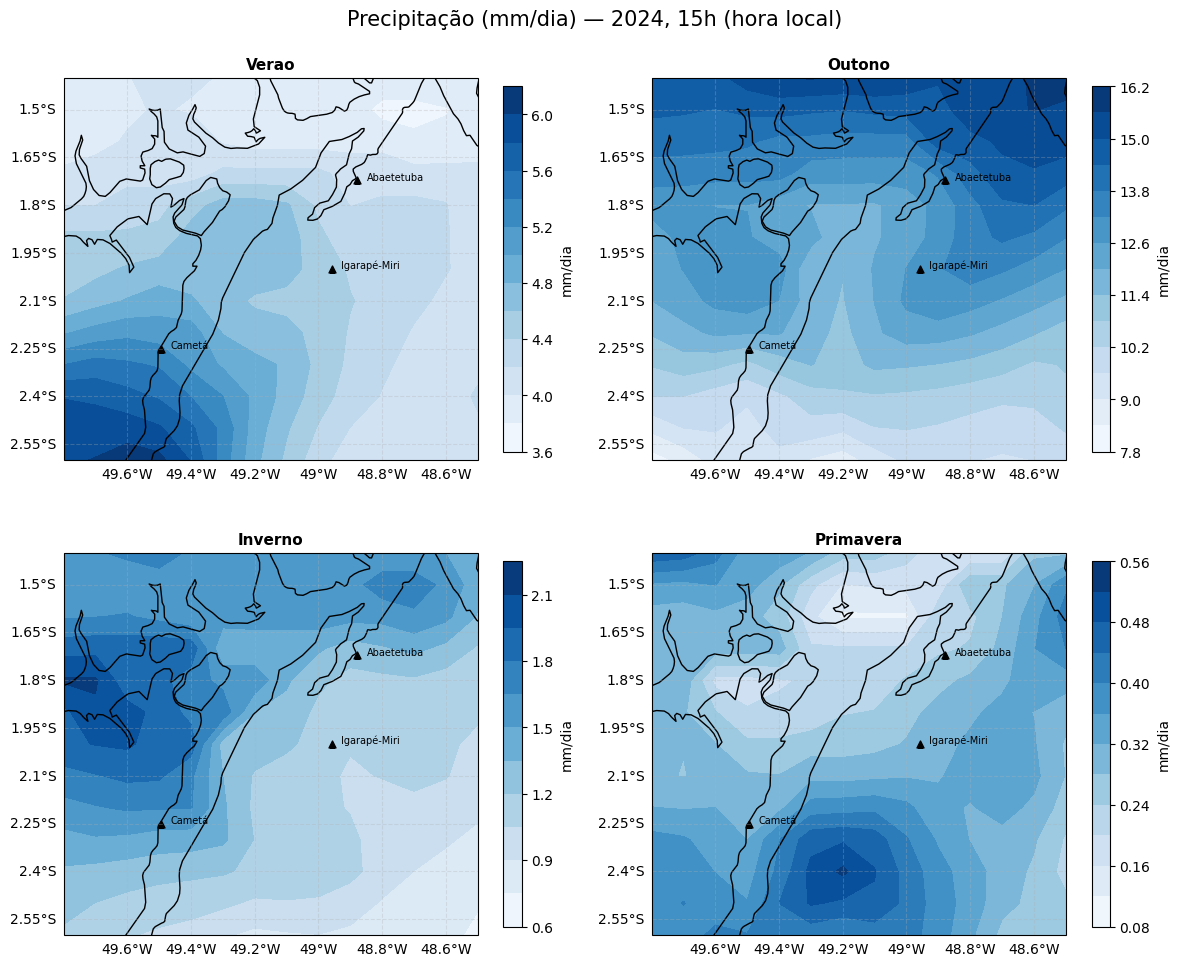

In [ ]:
# ==============================================================================
# MAPA 2 — PRECIPITAÇÃO
# ==============================================================================
plota_variavel_4_estacoes('precipitacao')

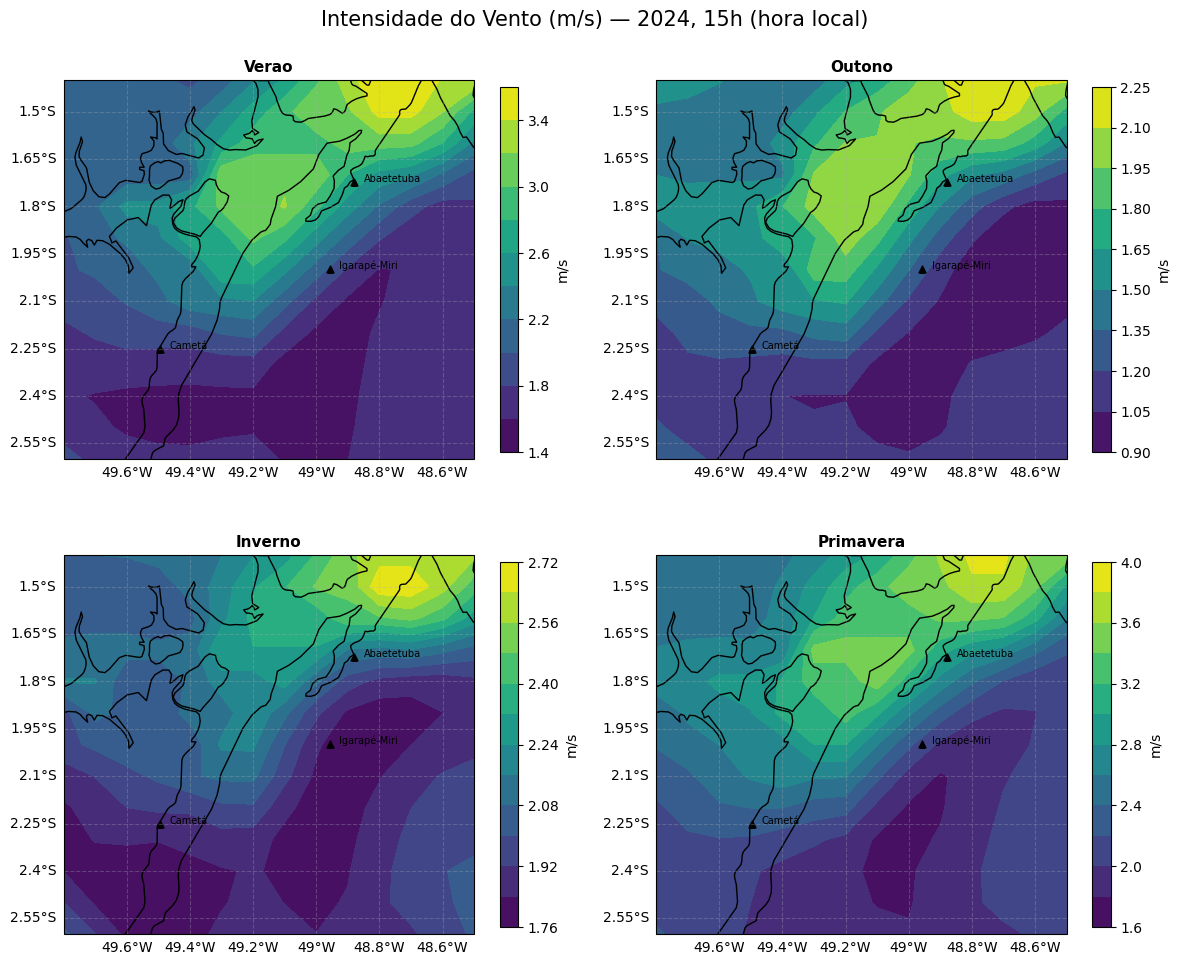

In [ ]:
# ==============================================================================
# MAPA 3 — INTENSIDADE DO VENTO
# ==============================================================================
plota_variavel_4_estacoes('vento')

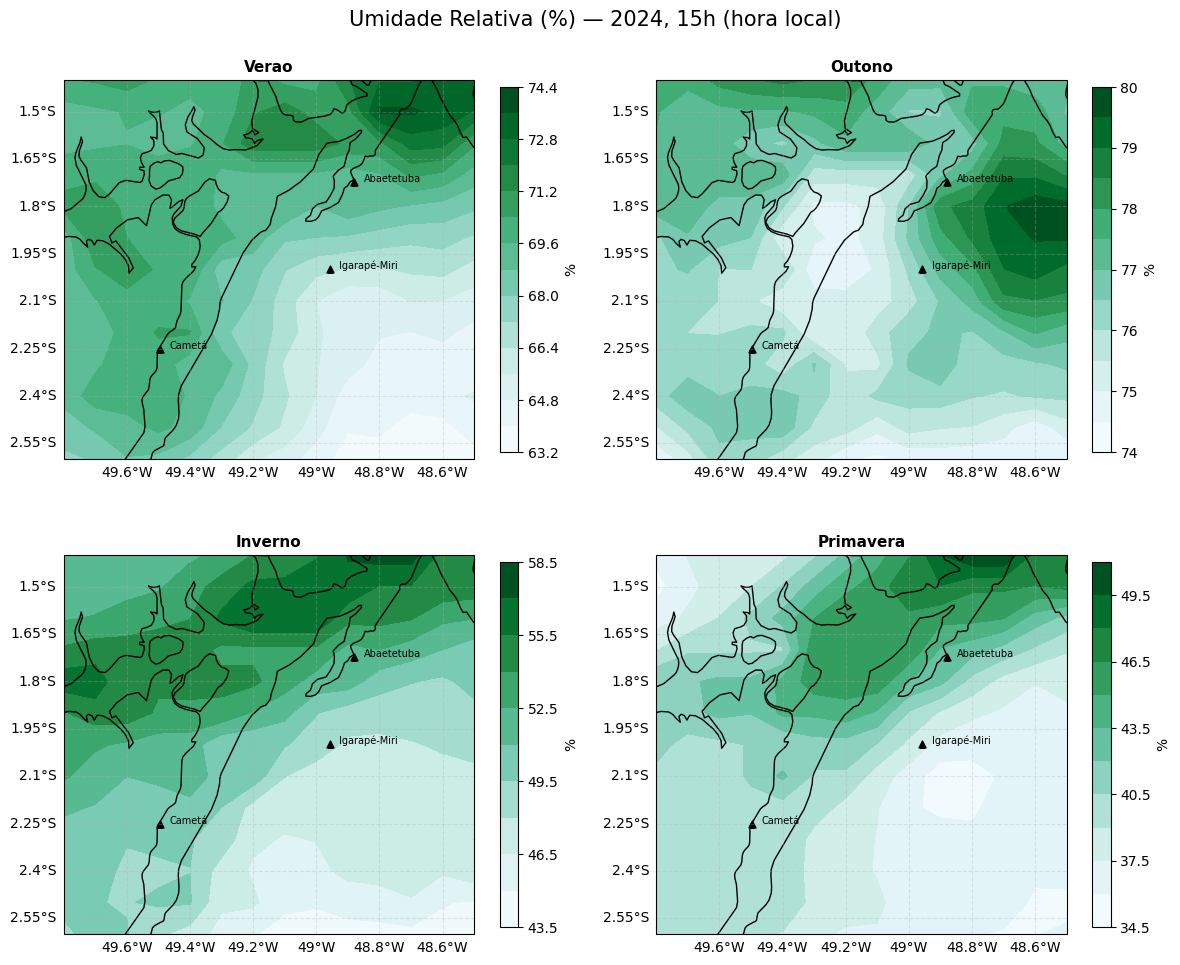

In [ ]:
# ==============================================================================
# MAPA 4 — UMIDADE RELATIVA
# ==============================================================================
plota_variavel_4_estacoes('umidade')

In [ ]:
# ==============================================================================
# PARTE 3 — TABELA COMPARATIVA: CLIMA x ÍNDICE DE PRODUÇÃO DE AÇAÍ
# O Índice de Produção NÃO vem de contagem por foto (não temos fotos datadas
# por estação) — vem do calendário de safra documentado pela Embrapa/IBGE
# para o açaí no Pará (safra: jul-dez ~70-80% da produção; entressafra:
# jan-jun ~20-30%), mapeado sobre as 4 estações meteorológicas usadas na
# Parte 1.
# ==============================================================================
import pandas as pd

indice_producao = {
    'Verao':     'Baixo',
    'Outono':    'Muito Baixo',
    'Inverno':   'Médio',
    'Primavera': 'Alto',
}

linhas = []
for est in ordem_estacoes:
    linhas.append({
        'Estação': est,
        'Precipitação (mm/dia)': float(dados_sazonais[est]['precipitacao'].mean().values),
        'Temperatura (°C)':      float(dados_sazonais[est]['temperatura'].mean().values),
        'Umidade (%)':           float(dados_sazonais[est]['umidade'].mean().values),
        'Vento (m/s)':           float(dados_sazonais[est]['vento'].mean().values),
        'Índice de Produção':    indice_producao[est],
    })

tabela_integrada = pd.DataFrame(linhas).round(2)
tabela_integrada

,Estação,Precipitação (mm/dia),Temperatura (°C),Umidade (%),Vento (m/s),Índice de Produção
0,Verao,4.48,30.06,68.22,2.03,Baixo
1,Outono,12.25,29.29,76.66,1.34,Muito Baixo
2,Inverno,1.31,32.54,50.11,2.00,Médio
3,Primavera,0.32,35.11,39.63,2.38,Alto


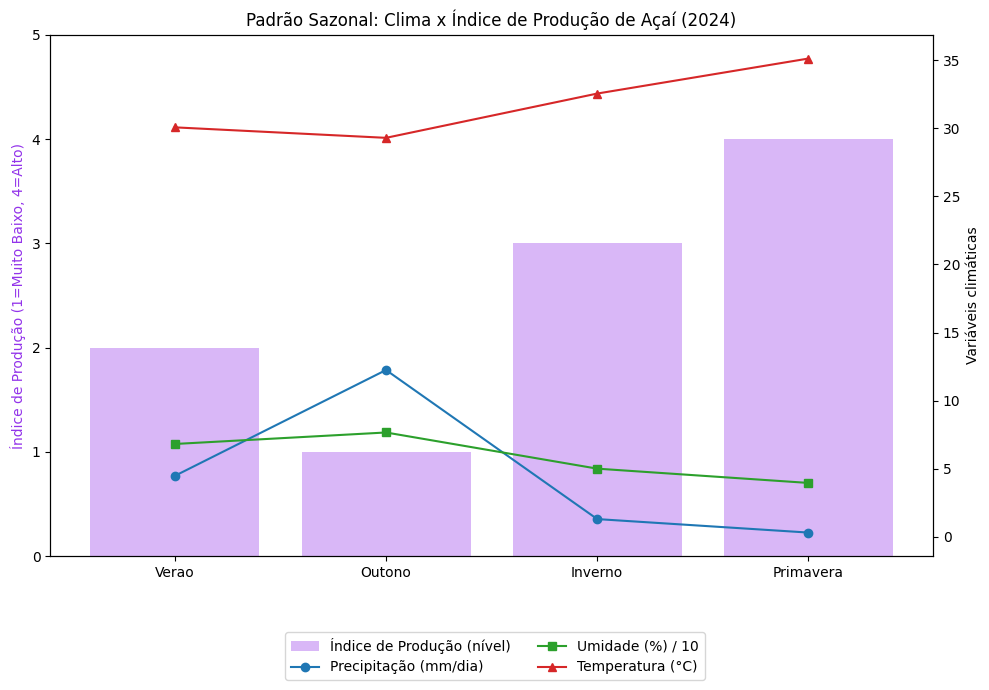

In [ ]:
# ==============================================================================
# GRÁFICO INTEGRADO: VARIÁVEIS CLIMÁTICAS x ÍNDICE DE PRODUÇÃO POR ESTAÇÃO
# ==============================================================================
nivel_producao = {'Muito Baixo': 1, 'Baixo': 2, 'Médio': 3, 'Alto': 4}
tabela_integrada['Nível de Produção'] = tabela_integrada['Índice de Produção'].map(nivel_producao)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(tabela_integrada['Estação'], tabela_integrada['Nível de Produção'],
        color='#9333ea', alpha=0.35, label='Índice de Produção (nível)')
ax1.set_ylabel('Índice de Produção (1=Muito Baixo, 4=Alto)', color='#9333ea')
ax1.set_ylim(0, 5)

ax2 = ax1.twinx()
ax2.plot(tabela_integrada['Estação'], tabela_integrada['Precipitação (mm/dia)'],
          marker='o', color='#1f77b4', label='Precipitação (mm/dia)')
ax2.plot(tabela_integrada['Estação'], tabela_integrada['Umidade (%)'] / 10,
          marker='s', color='#2ca02c', label='Umidade (%) / 10')
ax2.plot(tabela_integrada['Estação'], tabela_integrada['Temperatura (°C)'],
          marker='^', color='#d62728', label='Temperatura (°C)')
ax2.set_ylabel('Variáveis climáticas')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.title('Padrão Sazonal: Clima x Índice de Produção de Açaí (2024)')
plt.tight_layout()
plt.savefig('grafico_integrado_clima_producao.png', dpi=150, bbox_inches='tight')
plt.show()

## Discussão — Análise Integrada entre Clima e Produção de Açaí

Os dados climáticos de 2024 mostram um padrão sazonal marcado na região do
Baixo Tocantins (Igarapé-Miri, Cametá, Abaetetuba). É importante destacar que as estações aqui seguem a convenção astronômica do Hemisfério Sul (Verão = dez a fev, Outono = mar a mai, Inverno = jun a ago, Primavera = set a nov), e não a nomenclatura popular amazônica, onde "inverno" costuma designar o período chuvoso. Por estar próxima da linha do equador, a região não apresenta estações térmicas como em latitudes temperadas: quem domina a variação sazonal ali é a nebulosidade associada à chuva, e não a inclinação solar. O Outono concentra a maior precipitação média (12,51 mm/dia) e umidade relativa (76,75%), com temperatura mais amena (29,29°C), justamente por ser o período mais chuvoso e nublado do ano. A Primavera, por outro lado, é a estação mais seca (0,31 mm/dia), mais quente (35,32°C) e menos úmida (38,79%), reflexo da estiagem regional, com menos nuvens e mais radiação solar direta, e não de um "inverno frio" como se esperaria em outras regiões do Brasil.

Esse padrão climático coincide com o calendário de safra do açaizeiro
documentado pela Embrapa Amazônia Oriental. A floração ocorre no período
chuvoso (janeiro a junho) e a colheita se dá aproximadamente seis meses
depois, no período de estiagem (julho a dezembro). Isso explica por que o
Índice de Produção, baseado nesse calendário oficial e não em contagem
direta de imagens (já que não dispomos de fotos datadas por estação),
aparece mais alto justamente no Inverno e na Primavera, período de menor
chuva e maior temperatura.

**É importante destacar que essa é uma análise exploratória.** A correlação
observada entre variáveis climáticas e o Índice de Produção reflete um
padrão fenológico já conhecido e documentado na literatura agronômica, e
não uma relação causal derivada estatisticamente dos dados coletados neste
trabalho. Da mesma forma, qualquer relação entre o clima e a presença do
barbeiro (Parte 2) deve ser tratada como hipótese a ser investigada, e não
como conclusão. A ausência de dados de campo (armadilhas, coletas
entomológicas datadas) impede afirmar causalidade entre sazonalidade
climática, produção de açaí e risco de exposição ao vetor de doença de
Chagas.

In [ ]:
# ==============================================================================
# PARTE 3 (continuação) — MAPA DE APOIO: PROBABILIDADE DE AÇAÍ + USO DO SOLO
# ==============================================================================
!pip install -q earthengine-api geemap

import ee
import geemap

SEU_PROJETO = 'project-46dc522b-12fb-452b-964'

print("➡️ Conectando ao Earth Engine...")
try:
    ee.Initialize(project=SEU_PROJETO)
    print("✅ Earth Engine conectado.")
except Exception as e:
    print(f"⚠️ Falha na primeira tentativa: {e}")
    ee.Authenticate(force=True)
    ee.Initialize(project=SEU_PROJETO)

# ------------------------------------------------------------------------------
# ÁREA DE ESTUDO (dados e contorno usando exatamente a mesma área)
# ------------------------------------------------------------------------------
area_estudo_ee = ee.Geometry.Rectangle([lon_oeste, lat_sul, lon_leste, lat_norte])
regiao_foco = area_estudo_ee
ano_ee = 2023

# ------------------------------------------------------------------------------
# SENTINEL-2 (10m) - COMPOSIÇÃO SEM NUVENS E NDVI
# ------------------------------------------------------------------------------
def mascara_nuvens_s2(imagem):
    scl = imagem.select('SCL')
    mascara = (scl.neq(3).And(scl.neq(8)).And(scl.neq(9))
               .And(scl.neq(10)).And(scl.neq(11)))
    return imagem.updateMask(mascara)

s2_colecao = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(regiao_foco)
    .filterDate(f'{ano_ee}-01-01', f'{ano_ee}-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mascara_nuvens_s2)
)
s2_composicao = s2_colecao.median().clip(regiao_foco)
ndvi = s2_composicao.normalizedDifference(['B8', 'B4']).rename('NDVI')

# ------------------------------------------------------------------------------
# ÁGUA / RIOS (JRC) E DISTÂNCIA ATÉ A ÁGUA
# ------------------------------------------------------------------------------
agua_jrc = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence')
mascara_agua = agua_jrc.gt(50).unmask(0).clip(regiao_foco)

distancia_agua = (
    mascara_agua.fastDistanceTransform(256)
    .sqrt()
    .multiply(ee.Image.pixelArea().sqrt())
    .rename('dist_agua')
    .clip(regiao_foco)
)

# ------------------------------------------------------------------------------
# MAPBIOMAS - CLASSIFICAÇÃO DE USO DO SOLO (para contexto e máscara)
# ------------------------------------------------------------------------------
colecao_mae = ee.ImageCollection("projects/mapbiomas-public/assets/brazil/lulc/v1")
imagem_ano = ee.Image(
    colecao_mae.filter(ee.Filter.eq('year', ano_ee))
    .filter(ee.Filter.eq('version', 'v1')).first()
)
classificacao = imagem_ano.select('classification').clip(regiao_foco)

classes_excluidas = [24, 33, 30]  # urbano, água, mineração (fora do índice de açaí)
mascara_nao_urbana = classificacao.remap(classes_excluidas, [0, 0, 0], 1)

# ------------------------------------------------------------------------------
# ÍNDICE DE PROBABILIDADE DE AÇAÍ (NDVI + proximidade de água)
# ------------------------------------------------------------------------------
ndvi_score = ndvi.clamp(0.5, 0.9).unitScale(0.5, 0.9)
prox_agua_score = ee.Image(1).subtract(distancia_agua.clamp(0, 1000).unitScale(0, 1000))

indice_acai = (
    ndvi_score.multiply(0.6)
    .add(prox_agua_score.multiply(0.4))
    .updateMask(mascara_nao_urbana)
    .rename('indice_acai')
)

# Só mostra as áreas de probabilidade média/alta/muito alta (esconde baixa/muito baixa)
indice_acai_visivel = indice_acai.updateMask(indice_acai.gt(0.55))

# ------------------------------------------------------------------------------
# LEGENDA COMPLETA DO MAPBIOMAS
# ------------------------------------------------------------------------------
legenda_mapbiomas = {
    3:  ('Formação Florestal (Mata/Floresta Firme)',      '#1f8d49'),
    4:  ('Formação Savânica',                              '#7dc975'),
    5:  ('Mangue',                                          '#04381d'),
    6:  ('Floresta Alagável (Várzea, Açaí Nativo)',         '#026975'),
    9:  ('Silvicultura (Plantio de Árvores)',               '#7a5900'),
    11: ('Campo Alagado / Área Pantanosa',                  '#519799'),
    12: ('Formação Campestre',                              '#d6bc74'),
    15: ('Pastagem',                                         '#edde8e'),
    24: ('Área Urbanizada / Civilização',                   '#d4271e'),
    25: ('Outra Área Não Vegetada',                         '#db4d4f'),
    30: ('Mineração',                                        '#9c0027'),
    33: ('Rio, Lago e Oceano',                               '#2532e4'),
    35: ('Dendê (Palma de Óleo)',                           '#8c510a'),
    39: ('Soja',                                             '#ffd966'),
    41: ('Outras Lavouras Temporárias',                     '#f4a261'),
    48: ('Outras Lavouras Perenes (pode incluir açaí, cacau, guaraná, etc.)', '#8b4513'),
}

classes_legenda = list(legenda_mapbiomas.keys())
cores_legenda = [v[1] for v in legenda_mapbiomas.values()]
nomes_legenda = [v[0] for v in legenda_mapbiomas.values()]

vis_mapbiomas = {'min': 0, 'max': 62, 'palette': ['#ffffff'] * 63}
for c, cor in zip(classes_legenda, cores_legenda):
    vis_mapbiomas['palette'][c] = cor

vis_acai = {
    'min': 0, 'max': 1,
    'palette': ['ffffff', 'e9d5ff', 'c084fc', '9333ea', '581c87']
}

# ------------------------------------------------------------------------------
# CONTORNO DA ÁREA DE ESTUDO (sem preenchimento, linha grossa)
# ------------------------------------------------------------------------------
contorno_area_ee = ee.Image().byte().paint(
    featureCollection=ee.FeatureCollection([ee.Feature(area_estudo_ee)]),
    color=1, width=5
)

# ------------------------------------------------------------------------------
# MONTANDO O MAPA
# ------------------------------------------------------------------------------
Map = geemap.Map(center=[-1.98, -48.95], zoom=11, ee_initialize=False)
Map.add_basemap('HYBRID')

Map.addLayer(s2_composicao, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000, 'gamma': 1.3},
             'Sentinel-2 (Cor Real)', shown=False)
Map.addLayer(classificacao, vis_mapbiomas, 'MapBiomas - Uso do Solo', shown=True)
Map.addLayer(indice_acai_visivel, vis_acai, 'Probabilidade de Açaí (Média/Alta)',
             shown=True, opacity=0.75)
Map.addLayer(contorno_area_ee, {'palette': ['red']}, 'Área de Estudo (contorno)')

Map.add_legend(
    title="Uso do Solo (MapBiomas)",
    keys=nomes_legenda,
    colors=cores_legenda,
    position='bottomleft'
)

Map.add_legend(
    title="Probabilidade de Açaí",
    keys=['Média', 'Alta', 'Muito Alta'],
    colors=['c084fc', '9333ea', '581c87'],
    position='bottomright'
)

Map

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.6 MB/s eta 0:00:00
➡️ Conectando ao Earth Engine...
⚠️ Falha na primeira tentativa: Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.


Map(center=[-1.98, -48.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [ ]:
# ==============================================================================
# EXPORTAR O MAPA COMBINADO (MapBiomas + Probabilidade de Açaí + Contorno)
# Junta as camadas visuais numa imagem só, igual aparece no mapa interativo
# ==============================================================================
mapa_mapbiomas_vis = classificacao.visualize(**vis_mapbiomas)
mapa_acai_vis = indice_acai_visivel.visualize(**vis_acai)
mapa_contorno_vis = contorno_area_ee.visualize(palette=['red'])

mapa_combinado = mapa_mapbiomas_vis.blend(mapa_acai_vis).blend(mapa_contorno_vis)

salvar_mapa_estatico(mapa_combinado, 'mapa_combinado_final.png', regiao_foco, dimensoes='1000x1000')

✅ Salvo: mapa_combinado_final.png


In [ ]:
# ==============================================================================
# ADICIONAR A LEGENDA DIRETO NA IMAGEM (com quebra automática de texto)
# ==============================================================================
from PIL import Image, ImageDraw, ImageFont
import matplotlib

def quebrar_texto(desenho, texto, fonte, largura_maxima):
    """Quebra o texto em várias linhas para caber na largura disponível."""
    palavras = texto.split(' ')
    linhas = []
    linha_atual = ''

    for palavra in palavras:
        teste = (linha_atual + ' ' + palavra).strip()
        largura_teste = desenho.textlength(teste, font=fonte)
        if largura_teste <= largura_maxima:
            linha_atual = teste
        else:
            if linha_atual:
                linhas.append(linha_atual)
            linha_atual = palavra
    if linha_atual:
        linhas.append(linha_atual)
    return linhas

def adicionar_legenda(caminho_imagem, itens_legenda, caminho_saida, titulo="Legenda"):
    img = Image.open(caminho_imagem).convert('RGB')

    caminho_fontes = matplotlib.get_data_path() + '/fonts/ttf/'
    fonte_titulo = ImageFont.truetype(caminho_fontes + 'DejaVuSans-Bold.ttf', 15)
    fonte_texto = ImageFont.truetype(caminho_fontes + 'DejaVuSans.ttf', 12)

    largura_painel = 380
    largura_texto_disponivel = largura_painel - 55  # deixa margem pro quadradinho de cor

    # imagem temporária só pra poder medir texto antes de montar a final
    img_temp = Image.new('RGB', (10, 10))
    desenho_temp = ImageDraw.Draw(img_temp)

    # pré-calcula quantas linhas cada item vai ocupar, pra saber a altura total
    altura_linha = 18
    espaco_entre_itens = 10
    altura_necessaria = 50  # espaço do título
    linhas_por_item = []
    for nome, _ in itens_legenda:
        linhas = quebrar_texto(desenho_temp, nome, fonte_texto, largura_texto_disponivel)
        linhas_por_item.append(linhas)
        altura_necessaria += len(linhas) * altura_linha + espaco_entre_itens

    altura_final = max(img.height, altura_necessaria + 20)
    nova_imagem = Image.new('RGB', (img.width + largura_painel, altura_final), 'white')
    nova_imagem.paste(img, (0, 0))

    desenho = ImageDraw.Draw(nova_imagem)
    x_texto = img.width + 15
    largura_titulo_disponivel = largura_painel - 25
    y = 15

    for linha_titulo in quebrar_texto(desenho, titulo, fonte_titulo, largura_titulo_disponivel):
        desenho.text((x_texto, y), linha_titulo, fill='black', font=fonte_titulo)
        y += 22
    y += 10

    for (nome, cor_hex), linhas in zip(itens_legenda, linhas_por_item):
        desenho.rectangle([x_texto, y, x_texto + 18, y + 18], fill=cor_hex)
        for i, linha in enumerate(linhas):
            desenho.text((x_texto + 26, y + i * altura_linha), linha, fill='black', font=fonte_texto)
        y += len(linhas) * altura_linha + espaco_entre_itens

    nova_imagem.save(caminho_saida)
    print(f'✅ Salvo com legenda: {caminho_saida}')

itens_mapbiomas = [(nome, cor) for nome, cor in zip(nomes_legenda, cores_legenda)]
itens_acai = [('Média', '#c084fc'), ('Alta', '#9333ea'), ('Muito Alta', '#581c87')]

adicionar_legenda(
    'mapa_combinado_final.png',
    itens_mapbiomas + itens_acai,
    'mapa_combinado_com_legenda.png',
    titulo='Uso do Solo + Probabilidade de Açaí'
)

✅ Salvo com legenda: mapa_combinado_com_legenda.png
